In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the data directory
df = pd.read_csv('../data/internet_service_churn.csv')

# Display the first 5 rows to understand the data structure
display(df.head())

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


In [3]:
# Display basic information about the dataset (column types, non-null counts)
print("\n--- Dataset Information ---")
df.info()

# Calculate and display the number of missing values per column
print("\n--- Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   reamining_contract           50702 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 71893 non-null  float64
 8   upload_avg                   71893 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 6.1 MB

--- Missing Values ---
reamining_contract    21572
download_avg     

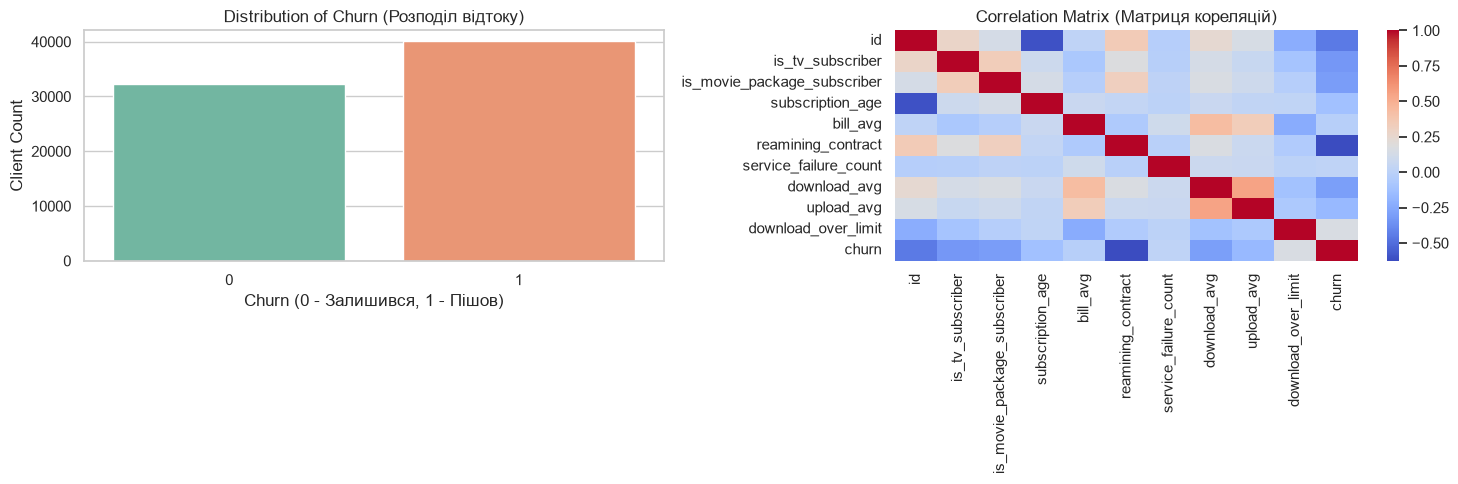

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots to make them cleaner
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# We use a countplot to see how many clients stayed (0) and how many left (1)
# Added 'hue' and 'legend=False' to comply with the latest Seaborn updates
sns.countplot(data=df, x='churn', ax=axes[0], hue='churn', palette='Set2', legend=False)
axes[0].set_title('Distribution of Churn (Розподіл відтоку)')
axes[0].set_xlabel('Churn (0 - Залишився, 1 - Пішов)')
axes[0].set_ylabel('Client Count')

# 2. Plotting the correlation matrix to see relationships between numerical features
# Select only numerical columns for correlation to avoid errors with categorical data
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
# Calculate the Pearson correlation coefficient between all numerical features
correlation_matrix = numeric_cols.corr()

# Draw a heatmap to visualize the correlation matrix
# 'coolwarm' colormap helps distinguish between positive (red) and negative (blue) correlations
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Matrix (Матриця кореляцій)')

# Adjust layout to prevent overlapping labels
plt.tight_layout()
# Display the plots
plt.show()

In [5]:
# Create a copy of the dataframe to avoid SettingWithCopyWarning during preprocessing
df_clean = df.copy()

# 1. Handle missing values in traffic columns by dropping those specific rows
# Since 381 rows is a very small fraction of our dataset (~0.5%), dropping them is safe
df_clean = df_clean.dropna(subset=['download_avg', 'upload_avg'])

# 2. Handle missing values in 'reamining_contract' by filling them with 0
# An assumption is made that a missing contract duration implies no active contract (0 years left)
df_clean['reamining_contract'] = df_clean['reamining_contract'].fillna(0)

# Verify that all missing values have been successfully handled
print("--- Missing Values After Processing ---")
missing_check = df_clean.isnull().sum()
print(missing_check[missing_check > 0])
print(f"\nNew dataset shape: {df_clean.shape}")

--- Missing Values After Processing ---
Series([], dtype: int64)

New dataset shape: (71893, 11)


In [6]:
from sklearn.preprocessing import StandardScaler

# 1. Drop the 'id' column as it has no predictive value for our machine learning model
df_clean = df_clean.drop(columns=['id'])

# 2. Identify numerical columns that need to be standardized
# We exclude binary columns (like 'is_tv_subscriber', 'churn') because they are already 0 or 1
cols_to_scale = ['subscription_age', 'bill_avg', 'reamining_contract',
                 'service_failure_count', 'download_avg', 'upload_avg']

# 3. Initialize the StandardScaler
scaler = StandardScaler()

# 4. Apply standardization to the selected numerical columns
# This ensures all features have a mean of 0 and standard deviation of 1
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

# Display the first 5 rows to verify that the numbers are now scaled (Standardized)
display(df_clean.head())

,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,1,0,4.684387,0.453666,-0.537157,-0.336792,-0.556575,-0.192699,0,0
1,0,0,2.844086,-1.441932,-0.747446,-0.336792,-0.689055,-0.426943,0,1
2,1,0,3.184517,-0.228749,-0.747446,-0.336792,-0.472986,-0.335282,0,1
3,0,0,2.178025,0.150371,-0.747446,0.884914,-0.689055,-0.426943,0,1
4,0,0,1.941204,-1.441932,-0.747446,-0.336792,-0.689055,-0.426943,0,1


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Define Features (X) and Target (y)
# X contains all columns except our target 'churn'
X = df_clean.drop(columns=['churn'])
# y is the target variable we want to predict
y = df_clean['churn']

# 2. Split the dataset into training and testing sets (80% train, 20% test)
# stratify=y ensures the same proportion of churned/retained customers in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize the Random Forest Classifier
# n_estimators=100 means we use 100 decision trees in our forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Train (fit) the model using the training data
rf_model.fit(X_train, y_train)

# 5. Make predictions on the unseen testing data
y_pred = rf_model.predict(X_test)

# 6. Evaluate the model using the metrics required by the Technical Task
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Print a detailed classification report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

--- Model Evaluation Metrics ---
Accuracy:  0.9421
Precision: 0.9588
Recall:    0.9363
F1 Score:  0.9474

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      6369
           1       0.96      0.94      0.95      8010

    accuracy                           0.94     14379
   macro avg       0.94      0.94      0.94     14379
weighted avg       0.94      0.94      0.94     14379



In [8]:
import pandas as pd
import numpy as np

def predict_churn(new_customer_data, model, scaler):
    """
    Predicts the probability of churn for a new customer based on their data.
    """
    # 1. Define feature names in the exact order used during model training
    feature_names = ['is_tv_subscriber', 'is_movie_package_subscriber',
                     'subscription_age', 'bill_avg', 'reamining_contract',
                     'service_failure_count', 'download_avg', 'upload_avg',
                     'download_over_limit']

    # 2. Convert the input list into a pandas DataFrame
    new_data_df = pd.DataFrame([new_customer_data], columns=feature_names)

    # 3. Scale numerical features using the pre-fitted scaler
    cols_to_scale = ['subscription_age', 'bill_avg', 'reamining_contract',
                     'service_failure_count', 'download_avg', 'upload_avg']
    new_data_df[cols_to_scale] = scaler.transform(new_data_df[cols_to_scale])

    # 4. Calculate the probability of churn (class 1)
    probability = model.predict_proba(new_data_df)[0][1]

    # 5. Output the results according to the technical requirements
    print(f"Churn Probability: {probability * 100:.2f}%\n")

    if probability > 0.5:
        print("Result: The client has a high probability of churn ⚠️")
    else:
        print("Result: The client has a low probability of churn ✅")


# --- Function Testing (Usage Example) ---
# Let's imagine a new customer: TV subscriber (1), no movie package (0),
# 2 years with us, $20 average bill, no remaining contract (0.0),
# 3 service failures, 10GB download, 2GB upload, no over limit (0).
new_customer = [1, 0, 2.0, 20, 0.0, 3, 10.0, 2.0, 0]

print("--- Prediction for the New Customer ---")
predict_churn(new_customer, rf_model, scaler)

--- Prediction for the New Customer ---
Churn Probability: 85.00%

Result: The client has a high probability of churn ⚠️


--- Prediction for the New Customer ---
Churn Probability: 85.00%

Result: The client has a high probability of churn ⚠️


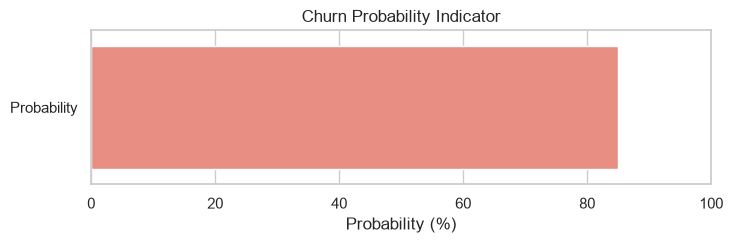

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def predict_churn(new_customer_data, model, scaler):
    """
    Predicts the probability of churn for a new customer based on their data
    and visualizes the result.
    """
    feature_names = ['is_tv_subscriber', 'is_movie_package_subscriber',
                     'subscription_age', 'bill_avg', 'reamining_contract',
                     'service_failure_count', 'download_avg', 'upload_avg',
                     'download_over_limit']

    new_data_df = pd.DataFrame([new_customer_data], columns=feature_names)

    cols_to_scale = ['subscription_age', 'bill_avg', 'reamining_contract',
                     'service_failure_count', 'download_avg', 'upload_avg']
    new_data_df[cols_to_scale] = scaler.transform(new_data_df[cols_to_scale])

    probability = model.predict_proba(new_data_df)[0][1]

    print(f"Churn Probability: {probability * 100:.2f}%\n")

    if probability > 0.5:
        print("Result: The client has a high probability of churn ⚠️")
        color = 'salmon'
    else:
        print("Result: The client has a low probability of churn ✅")
        color = 'lightgreen'

    # --- Data Visualization of the Result ---
    plt.figure(figsize=(8, 2))
    sns.barplot(x=[probability * 100], y=['Probability'], color=color)
    plt.xlim(0, 100)
    plt.title('Churn Probability Indicator')
    plt.xlabel('Probability (%)')
    plt.show()

# --- Function Testing ---
new_customer = [1, 0, 2.0, 20, 0.0, 3, 10.0, 2.0, 0]
print("--- Prediction for the New Customer ---")
predict_churn(new_customer, rf_model, scaler)

In [10]:
import joblib

# --- Save the trained model and scaler for the Streamlit application ---

# We use joblib to serialize the Random Forest model and the StandardScaler
# Make sure to save them in a directory where your app.py can access them
joblib.dump(rf_model, '../src/rf_model.pkl')
joblib.dump(scaler, '../src/scaler.pkl')

print("Model and scaler have been successfully saved to the 'src' directory!")

Model and scaler have been successfully saved to the 'src' directory!
